In [3]:
import networkx as nx
import matplotlib.pyplot as plt
G = nx.read_edgelist('107.edges', create_using=nx.Graph(), nodetype=int)

print(f"Total number of users (nodes): {G.number_of_nodes()}")
print(f"Total number of friendships (edges): {G.number_of_edges()}")


Total number of users (nodes): 1034
Total number of friendships (edges): 26749


In [4]:
def find_mutual_friends(graph, user1, user2):
    if user1 not in graph.nodes or user2 not in graph.nodes:
        return "One or both users not found."
    friends1 = set(graph.neighbors(user1))
    friends2 = set(graph.neighbors(user2))
    return friends1 & friends2


In [5]:
print(list(G.nodes)[:20])


[953, 1323, 1789, 1707, 1175, 1059, 1329, 1559, 1804, 1898, 1622, 1520, 1200, 1202, 1449, 1836, 1156, 1605, 1149, 1173]


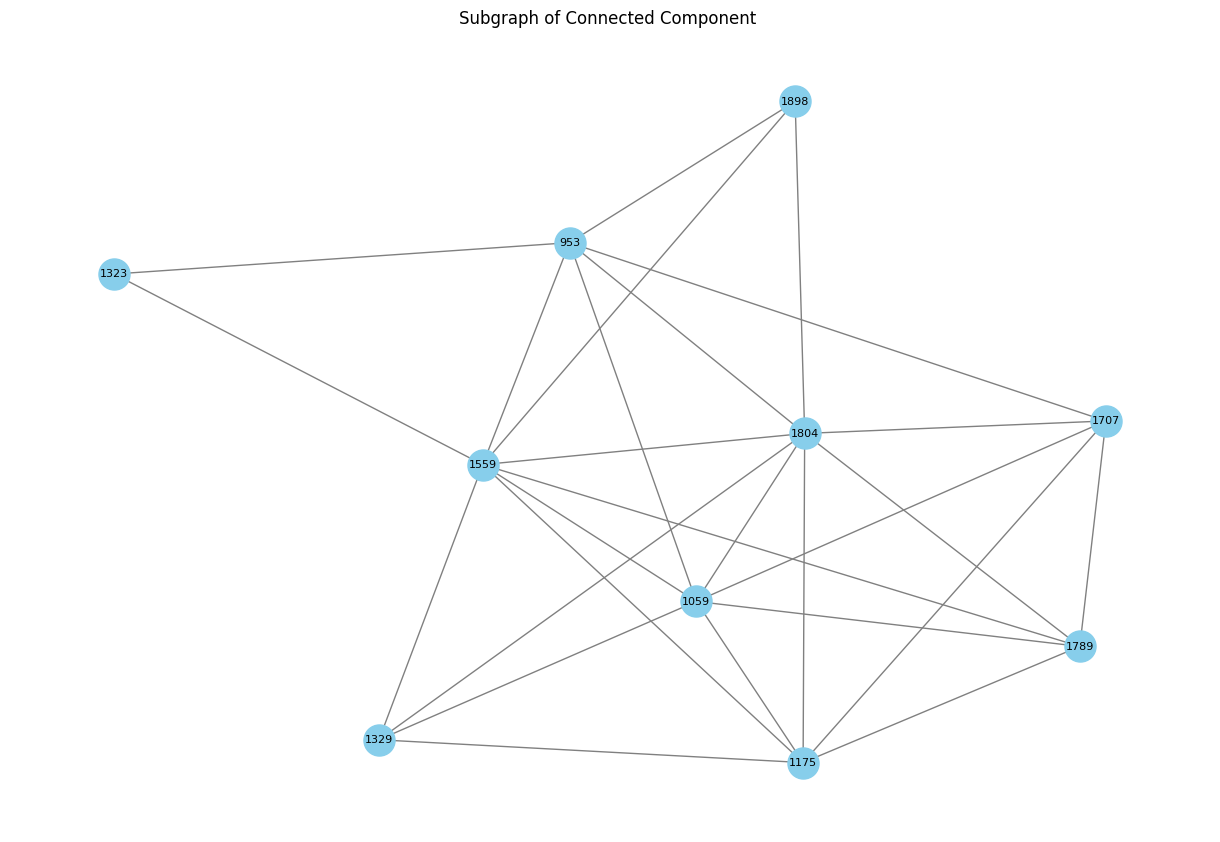

In [7]:
largest_cc = max(nx.connected_components(G), key=len)
H = G.subgraph(largest_cc).copy()


nodes_subset = list(H.nodes)[:10]
H_small = H.subgraph(nodes_subset)


pos = nx.kamada_kawai_layout(H_small)
plt.figure(figsize=(12, 8))
nx.draw(H_small, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500, font_size=8)

#plt.figure(figsize=(12, 8))

#nx.draw(H_small, pos, with_labels=True, node_color='skyblue', edge_color='gray', node_size=500, font_size=8)
plt.title("Subgraph of Connected Component ")
plt.show()



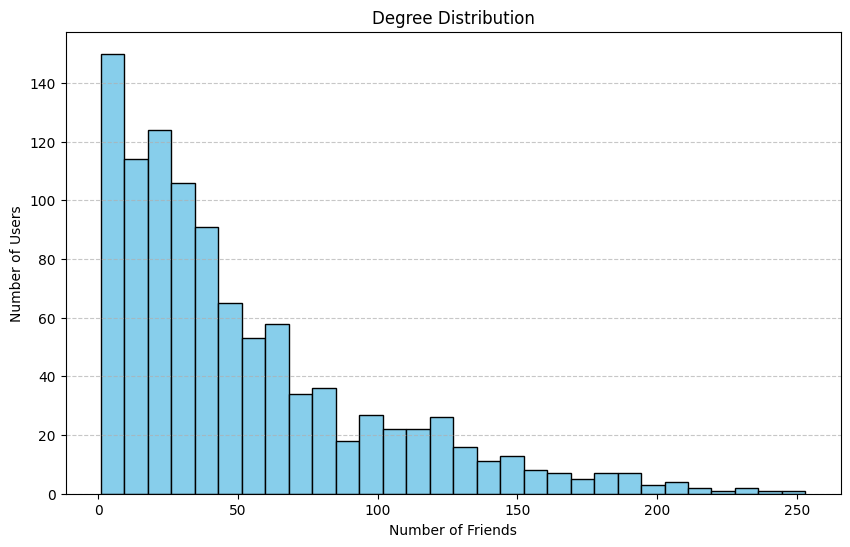

In [13]:
degrees = [G.degree(n) for n in G.nodes()]
plt.figure(figsize=(10, 6))
plt.hist(degrees, bins=30, color='skyblue', edgecolor='black')
plt.title('Degree Distribution')
plt.xlabel('Number of Friends')
plt.ylabel('Number of Users')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [32]:
def recommend_friend(graph, user):
    if user not in graph.nodes:
        return "User not found."
    friends = set(graph.neighbors(user))
    potential = {}

    for f in friends:
        fof = set(graph.neighbors(f))
        for person in fof:
            if person != user and person not in friends:
                potential[person] = potential.get(person, 0) + 1

    return sorted(potential.items(), key=lambda x: x[1], reverse=True)[:5]




In [34]:
some_user = list(G.nodes)[1]   
print("Testing recommendation for user:", some_user)
print(recommend_friend(G, some_user))


Testing recommendation for user: 1323
[(1804, 63), (1800, 59), (1589, 56), (1431, 55), (1613, 55)]


In [27]:
top_users = sorted(G.degree, key=lambda x: x[1], reverse=True)[:5]
print("Top 5 Most Connected Users:")
for user, degree in top_users:
    print(f"User {user} has {degree} friends")


Top 5 Most Connected Users:
User 1888 has 253 friends
User 1800 has 244 friends
User 1663 has 234 friends
User 1352 has 233 friends
User 1730 has 225 friends


In [30]:
def suggest_top_mutual_friend(graph, user):
    if user not in graph:
        return "User not found in graph."
    
    friends = set(graph.neighbors(user))
    mutual_counts = {}

    for friend in friends:
        friends_of_friend = set(graph.neighbors(friend))
        for fof in friends_of_friend:
            if fof != user and fof not in friends:
                mutual_counts[fof] = mutual_counts.get(fof, 0) + 1

    if not mutual_counts:
        return "No potential friends to suggest."

    # Get the person with the highest number of mutual friends
    best_suggestion = max(mutual_counts.items(), key=lambda x: x[1])
    return f"Suggested friend for user {user}: {best_suggestion[0]} (with {best_suggestion[1]} mutual friends)"
print(suggest_top_mutual_friend(G,1786))

Suggested friend for user 1786: 1345 (with 42 mutual friends)
